In [1]:
#Import#

from cellpose import models, core, io, plot
from cellpose import train
from cellpose import metrics
import numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import imageio.v2 as imageio
import os
import skimage.filters
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from skimage import exposure
from skimage.measure import regionprops
from skimage.segmentation import watershed
from skimage.segmentation import mark_boundaries
from skimage import img_as_float
from skimage.filters import sobel
from skimage.feature import blob_dog
from skimage import data, color, filters, segmentation, measure, morphology
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from scipy.ndimage import generate_binary_structure, binary_dilation
import pandas as pd
from glob import glob
import cv2
import re


import time

In [2]:
#Data input from the User

folder_path = r'Y:\Group Members\Valentin Aubry\01_Data\Data_Andreas_single'  # The r in r'Example\Pathway' is very important to get the raw input


# Check if the folder is empty or even exists
if os.path.isdir(folder_path) == True:
    print("Folder Path exists")

    # Getting the list of directories
    dir = os.listdir(folder_path)
    
    # Checking if the list is empty or not
    if len(dir) == 0:
        print("Empty directory")
    else:
        print("Not empty directory")
else:
    print("Folder path not found")

Folder Path exists
Not empty directory


In [3]:
# Data Loading


# High Throughput Data Loading
Cy5_data = glob(os.path.join(folder_path, '*Cy5 SEM.tif'))
DAPI_data = glob(os.path.join(folder_path, '*DAPI SEM.tif'))
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))
FITC_data = glob(os.path.join(folder_path, '*FITC SEM.tif'))
TRITC_data = glob(os.path.join(folder_path, '*TRITC SEM.tif'))


# Sorting the data in case it isn't yet
Cy5_data.sort()
DAPI_data.sort()
DAPI_mask_data.sort()
FITC_data.sort()
TRITC_data.sort()


# Displaying all the data that was loaded
for i in range (len(DAPI_data)):
    print(os.path.basename(Cy5_data[i]))
    print(os.path.basename(DAPI_data[i]))
    print(os.path.basename(DAPI_mask_data[i]))
    print(os.path.basename(FITC_data[i]))
    print(os.path.basename(TRITC_data[i]))





ATR2_24h--W00044--P00021--Z00000--T00000--Cy5 SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM_seg.npy
ATR2_24h--W00044--P00021--Z00000--T00000--FITC SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--TRITC SEM.tif


In [4]:
# Loading Functions

# Function to check if a potential foci is X-times brighter than the immediate Background (preventing false positives)
def local_contrast(image, coordinates, bright_percentage, contrast_threshold=2.5):
    """
    Filter detected foci by comparing their intensity to local background.
    
    This function confirms foci as true positives only if they are significantly
    brighter than their immediate surroundings, reducing false positive detections
    from background noise or imaging artifacts.
    
    Parameters:
    -----------
    image : numpy.ndarray
        2D array of the fluorescence image (grayscale) where foci are detected.
        Typically a single channel (e.g., TRITC, FITC) image.
    
    coordinates : numpy.ndarray
        Array of shape (N, 2) containing (y, x) coordinates of potential foci
        detected by peak_local_max or similar detection methods.
    
    bright_percentage : int or float
        Percentile (0-100) used to define local background brightness.
        For example:
        - 50 compares to median brightness around the focus
        - 25 compares to dimmer regions (more stringent filtering)
        - 75 compares to brighter regions (less stringent filtering)
    
    contrast_threshold : float, optional (default=2.5)
        Minimum contrast ratio between focus and local background.
        Focus intensity must be > (local_background * contrast_threshold).
        Higher values = more stringent filtering (fewer false positives).
        Typical values: 1.5-3.0
    
    Returns:
    --------
    numpy.ndarray
        Array of shape (M, 2) containing confirmed foci coordinates where M <= N.
        Returns empty array of shape (0, 2) if no foci pass the contrast filter.
    
    Notes:
    ------
    - Uses an 11x11 pixel square (±5 pixels) around each potential focus
    - Edge cases are handled by clamping to image boundaries
    - Empty return is shaped (0, 2) for compatibility with downstream processing
    """
    confirmed_coords = []  #Empty array to store the filtered coordinates in later
    for i in coordinates:
        y, x = i   # Get the coordinates for each foci 
        y_min, y_max = max(0, y-5), min(image.shape[0], y+6)  #setting boudaries from y-5 to y+5(Y+6 gets excluded as upper border)
        x_min, x_max = max(0, x-5), min(image.shape[1], x+6)
        square = image[y_min:y_max, x_min:x_max]  #creating a square with the defined boudaries

        potential_foci = image[y, x]
        local_background = np.percentile(square, bright_percentage)  # Selects a pixel with the brightness in the defined percentage for comparison

        if potential_foci > local_background * contrast_threshold:  # If the potential foci is X-times brighter than the selected background, the foci is confirmed
            confirmed_coords.append(i)
            
    # returns the confirmed foci coordinates or if there are none creates an empty array to not crash the display below
    return np.array(confirmed_coords) if confirmed_coords else np.array([]).reshape(0, 2)





def save_dataframe_to_csv(df, folder_path, base_name, data_type):
    """
    Save a DataFrame to CSV with Excel-compatible formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to save
    folder_path : str
        Directory where file will be saved
    base_name : str
        Base filename (without extension)
    data_type : str
        Type of data being saved (e.g., 'foci', 'nucleus', 'cytoplasm')
    """
    filename = f"{folder_path}/{base_name}--{data_type}_DF_SEM.csv"
    
    # Write sep=, line for Excel compatibility
    with open(filename, 'w') as f:
        f.write('sep=,\n')
    
    # Write data with header
    df.to_csv(filename, mode='a', header=True, index=False)

In [6]:
'''
For the Nucleus that has no foci for sure and shouldn't have any:
- Picture 3, ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM.tif
- Nucleus 100

For the Nucleus that has a clear fixed amount of foci that should not diminish or increase: 
- Picture 3
- Nucleus 42, 6 Foci



'''

"\nFor the Nucleus that has no foci for sure and shouldn't have any:\n- Picture 3, ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM.tif\n- Nucleus 100\n\nFor the Nucleus that has a clear fixed amount of foci that should not diminish or increase: \n- Picture 3\n- Nucleus 42, 6 Foci\n\n\n\n"

In [19]:
picture_number = 0
cell_number = 30

print('-----------------------------\nPicture Number '+str(picture_number)+'\nNucleus Number '+str(cell_number)+'\n-----------------------------\n-----------------------------')


#High Throughput Data Loading Loop
#for i in range (len(DAPI_data)):
i = picture_number

#Loading the picture on i position from each channel
Cy5_pic = imageio.imread(Cy5_data[i])
DAPI_pic = imageio.imread(DAPI_data[i])
DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)
FITC_pic = imageio.imread(FITC_data[i])
TRITC_pic = imageio.imread(TRITC_data[i])

TRITC_pic = img_as_float(TRITC_pic)


# Defining the amount of steps in want to make to reach a parameter value
howmanysteps = 1
#minimal_brightness = np.linspace(0, 100, int(howmanysteps))



for k in range (howmanysteps):   

    #low_sigma = (1.99/steps)*(k+1)
    #high_sigma = 1+(k*0.1)
    #mode = ['reflect', 'constant', 'nearest', 'mirror', 'wrap']
    #upper_brightness = 100-(k*1)
    square_size = 6
    backgrnd_brightness = 52.5
    contrast_threshold = 1.75
    
    #almost_max = np.percentile(TRITC_pic[TRITC_pic > 0], minimal_brightness[k])
    almost_max = np.percentile(TRITC_pic[TRITC_pic > 0], 99)# Gets the brightness of the 99th percentile of brightest pixels to reduce outliers
    
    foci_distance_filt = 2
    foci_threshold_filt = almost_max
    
    foci_distance_unfilt = 2
    foci_threshold_unfilt = almost_max
    
    tolerance = 1  # Distance at which the detected foci in the gamma adjusted TRIC picture are confirmed if there is one also detected on the DoG picture
    
    
    
    
    # Extract the name of the picture that will be analyzed to later be able to save it accordingly
    base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')
    
    # Extract the actual mask array
    masks = DAPI_mask_pic  # This contains the segmented regions
    
    # Function to generate a picture for every cell that cellpose recognized
    #for j in range (1,len(np.unique(masks))):
    j = cell_number
    
    # Defining which nucleus from the Segmentation Mask is isolated
    cellnumber = j
    masks_reduced = (masks == cellnumber)  
    
    # Overlaying DAPI mask to TRITC
    masked_TRITC = np.ma.masked_where(masks_reduced == 0, masks_reduced)  
    
    
    
    
    # Applying the mask to the TRITC picture by setting the background to 0 (black)
    isolated_TRITC = TRITC_pic.copy()  # copying the original picture so that it doesn't get changed
    isolated_TRITC[masks_reduced==False] = 0  # assign the pixels from the TRITC picture copy the value 0 (black), where the mask has the value false (background)
    
    #gamma_TRITC = skimage.exposure.adjust_gamma(isolated_TRITC, gamma=1)
    #isolated_TRITC = exposure.rescale_intensity(isolated_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))
    
    
    # Applying a difference of gaussian filter on the picture --> enhances peaks and smooths out background
    filtered_TRITC = skimage.filters.difference_of_gaussians(isolated_TRITC, low_sigma=1, high_sigma=2, mode='nearest', cval=0, channel_axis=None, truncate=4.0)
    filtered_TRITC = np.clip(filtered_TRITC, 0, None)
    
    #filtered_TRITC = skimage.exposure.adjust_gamma(filtered_TRITC, gamma=1)
    filtered_TRITC = exposure.rescale_intensity(filtered_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))
    
    
    # Detecting the coordinates of the peaks in the unfiltered picture
    coordinates_filtered = peak_local_max(
        filtered_TRITC, 
        min_distance=foci_distance_filt,        # This is just the minimal distance of how close two foci can be detected next to eachother
        threshold_abs=foci_threshold_filt       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
    )
    
    # Detecting the coordinates of the peaks in the filtered picture
    coordinates_unfiltered = peak_local_max(
        isolated_TRITC, 
        min_distance=foci_distance_unfilt,        # This is just the minimal distance of how close two foci can be detected next to eachother
        threshold_abs=foci_threshold_unfilt       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
    )
    
    def local_contrast(image, coordinates, bright_percentage, square_size, contrast_threshold=2.5,):
        confirmed_coords = []  #Empty array to store the filtered coordinates in later
        for i in coordinates:
            y, x = i   # Get the coordinates for each foci 
            y_min, y_max = max(0, y-square_size), min(image.shape[0], y+1+square_size)  #setting boudaries from y-5 to y+5(Y+6 gets excluded as upper border)
            x_min, x_max = max(0, x-square_size), min(image.shape[1], x+1+square_size)
            square = image[y_min:y_max, x_min:x_max]  #creating a square with the defined boudaries
    
            potential_foci = image[y, x]
            local_background = np.percentile(square, bright_percentage)  # Selects a pixel with the brightness in the defined percentage for comparison
    
            if potential_foci > local_background * contrast_threshold:  # If the potential foci is X-times brighter than the selected background, the foci is confirmed
                confirmed_coords.append(i)
                
        # returns the confirmed foci coordinates or if there are none creates an empty array to not crash the display below
        return np.array(confirmed_coords) if confirmed_coords else np.array([]).reshape(0, 2)
        
    # Running the above defined function on the filtered and unfiltered coordinates
    coordinates_unfiltered = local_contrast(isolated_TRITC, coordinates_unfiltered, backgrnd_brightness, square_size, contrast_threshold=contrast_threshold)
    coordinates_filtered = local_contrast(filtered_TRITC, coordinates_filtered, backgrnd_brightness, square_size, contrast_threshold=contrast_threshold)
    
    
    # Find foci that are close in both sets (within tolerance distance)
    distances = cdist(coordinates_unfiltered, coordinates_filtered)  # calculate the distance between filtered foci and unfiltered foci
    tolerance = tolerance  # pixels of how far apart the foci maximally can be on both pictures to be confirmed
    
    
    if coordinates_unfiltered.size > 0 and coordinates_filtered.size > 0:
        # Keep foci from unfiltered that have a match in filtered
        coordinates = coordinates_unfiltered[np.min(distances, axis=1) <= tolerance]  # np.min: find minimal distance between nearest foci, 
        #<=tolerance: creates a boolean array with true for each unfiltered foci with a filtered one within tolerance, 
        #coordinates_unfiltered[]: keeps only foci that are True
    else:
        coordinates = np.array([]).reshape(0, 2)  #generating an epmty array, so that the visualization down below doesn't get an error if no foci was detected
    
    

   # print('minimal_brightness: '+str(almost_max[k])+' Foci detected: '+str(len(coordinates))+'\n-----------------------')
    



-----------------------------
Picture Number 0
Nucleus Number 30
-----------------------------
-----------------------------


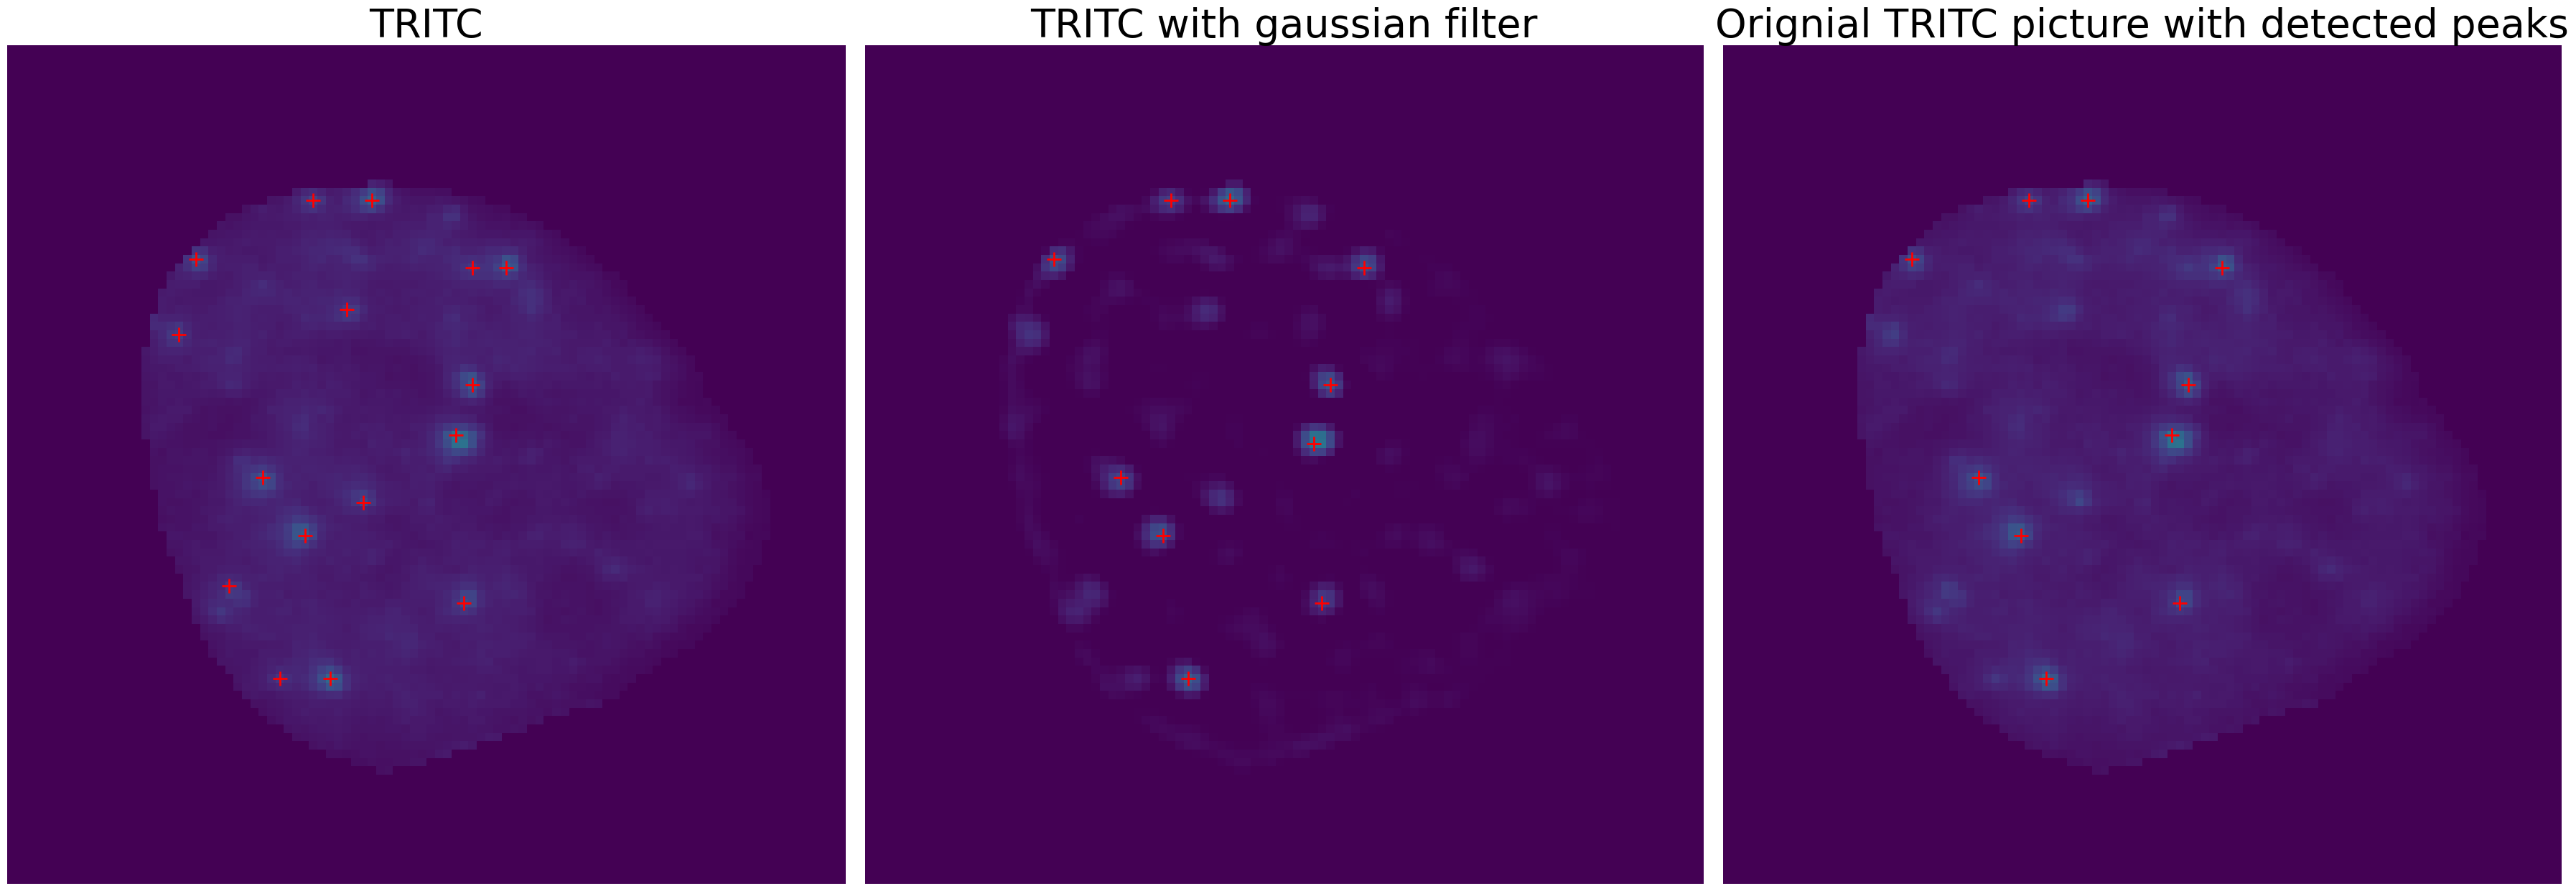

In [20]:
# Displaying the original picture with an isolated cell and the filtered picture
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(36, 12))

# Finding the middle coordinates for the cell we want to look at
props = regionprops(masks_reduced.astype(int))  # Calculate region properties (centroid, area, etc.) for the cell mask
if props:  # Check if any regions (props) were found in the mask
    centroid_y, centroid_x = props[0].centroid  # Extract y and x coordinates of the cell's center, which is the only region (props[0])

# To stop the possibility of going out of boundary
if int(centroid_y) < 50:
    centroid_y = 50
if int(centroid_x) < 50:
    centroid_x = 50

# Initial crop
origin = ((int(centroid_y)-50),(int(centroid_x)-50))
#origin = (0,0)
size = (100,100) #~100x100 for single cell
#size = (2048,2048)


# Original TRITC Picture with isolated cell
axes[0].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_unfiltered = coordinates_unfiltered - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_unfiltered[:, 0] >= 0) & (adjusted_unfiltered[:, 0] < size[0]) & \
       (adjusted_unfiltered[:, 1] >= 0) & (adjusted_unfiltered[:, 1] < size[1])
visible_unfiltered = adjusted_unfiltered[mask]

# Plot the peaks
axes[0].plot(visible_unfiltered[:, 1], visible_unfiltered[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[0].axis('off')
axes[0].set_title('TRITC', fontsize = 40)

# Filtered TRITC picture with isolated cell
axes[1].imshow(filtered_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max()) 

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_filtered = coordinates_filtered - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_filtered[:, 0] >= 0) & (adjusted_filtered[:, 0] < size[0]) & \
       (adjusted_filtered[:, 1] >= 0) & (adjusted_filtered[:, 1] < size[1])
visible_filtered = adjusted_filtered[mask]

# Plot the peaks
axes[1].plot(visible_filtered[:, 1], visible_filtered[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[1].axis('off')
axes[1].set_title('TRITC with gaussian filter', fontsize = 40)

# Original TRITC Picture with isolated cell
axes[2].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_coords = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_coords[:, 0] >= 0) & (adjusted_coords[:, 0] < size[0]) & \
       (adjusted_coords[:, 1] >= 0) & (adjusted_coords[:, 1] < size[1])
visible_coords = adjusted_coords[mask]

# Plot the peaks
axes[2].plot(visible_coords[:, 1], visible_coords[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[2].axis('off')
axes[2].set_title('Orignial TRITC picture with detected peaks', fontsize = 40)

plt.tight_layout()
plt.show()

In [21]:
#Watershed Segmentation on DoG filtered TRITC Picture with the detected peaks as starting points
water_threshold = foci_threshold_filt

markers = np.zeros_like(filtered_TRITC, dtype=int)  # creates an array with the same shape and size as isolated_TRITC but all zeros
for i, (x, y) in enumerate(coordinates, start=1):  
    markers[x, y] = i  # gives the previously created zero array a number at the point of the foci coordinates

# Use original markers without dilation - watershed will keep them separate
#markers_expanded = markers.copy()


# One of these 
distance = ndi.distance_transform_edt(filtered_TRITC < water_threshold)  # calculates Distance to the nearest background
gradient = sobel(filtered_TRITC)


# Ensure all marker positions are included in the mask
watershed_mask = (filtered_TRITC > water_threshold) | (markers > 0)

# Creates a mask that contains all the pixels that would get segmented in the watershed and the pixel that was detected as the center of the foci
water_labels = watershed(gradient, markers, mask=watershed_mask)  # Applying Watershed, -distance to invert map height map (to make peaks to valleys)
# The watershed was now done within the borders of the previously defined mask


# To get all the data from the watershed
for region_id in range(1, markers.max() + 1):
    spot_mask = (water_labels == region_id)
    spot_area = np.sum(spot_mask)
    spot_intensity = np.sum(isolated_TRITC[spot_mask])





In [16]:
#Watershed Segmentation with the help of blob_dog
TRITC_blob = blob_dog(isolated_TRITC, min_sigma=1, max_sigma=2, threshold=foci_threshold_filt*0.003)

# Creates an arry with the same size as the picture filled with zeros
markers = np.zeros_like(isolated_TRITC, dtype=int)

# Creates a Mask with the detected blobs as starting regions
#for i, (by, bx, sigma) in enumerate(TRITC_blob, start=1): # Gives each blob an individual number i
for i, (by, bx) in enumerate(coordinates, start=1): # Gives each blob an individual number i
    # Get sigma from blob_dog if available, otherwise use default
    if i-1 < len(TRITC_blob):
        sigma = TRITC_blob[i-1][2]  # Extract sigma from corresponding blob
    else:
        sigma = 1.5  # Default sigma if blob_dog didn't detect enough blobs
    
    print(f"Coordinate {i}: ({by}, {bx}), sigma: {sigma}")

    
    rr, cc = np.ogrid[:isolated_TRITC.shape[0], :isolated_TRITC.shape[1]] # Creates 2 arrays rr and cc with the same size as the picture for indexing
    mask = (rr - by)**2 + (cc - bx)**2 <= (sigma * 1.5)**2 # Creates Mask where all the blob regions are True (radius proportional to blobsize)
    markers[mask] = i # All blob regions get a unique number i

# Creates an elevation map where edges (high change in intensity) are high and flat regions (low/no change in intensity) are low
elevation_map = sobel(isolated_TRITC)

blob_labels = segmentation.watershed(elevation_map, markers) # Does the watershed segmentation with the elevation map as base and the markers(previously defined blob regions) for starting 

Coordinate 1: (326, 151), sigma: 1.0


<function matplotlib.pyplot.show(close=None, block=None)>

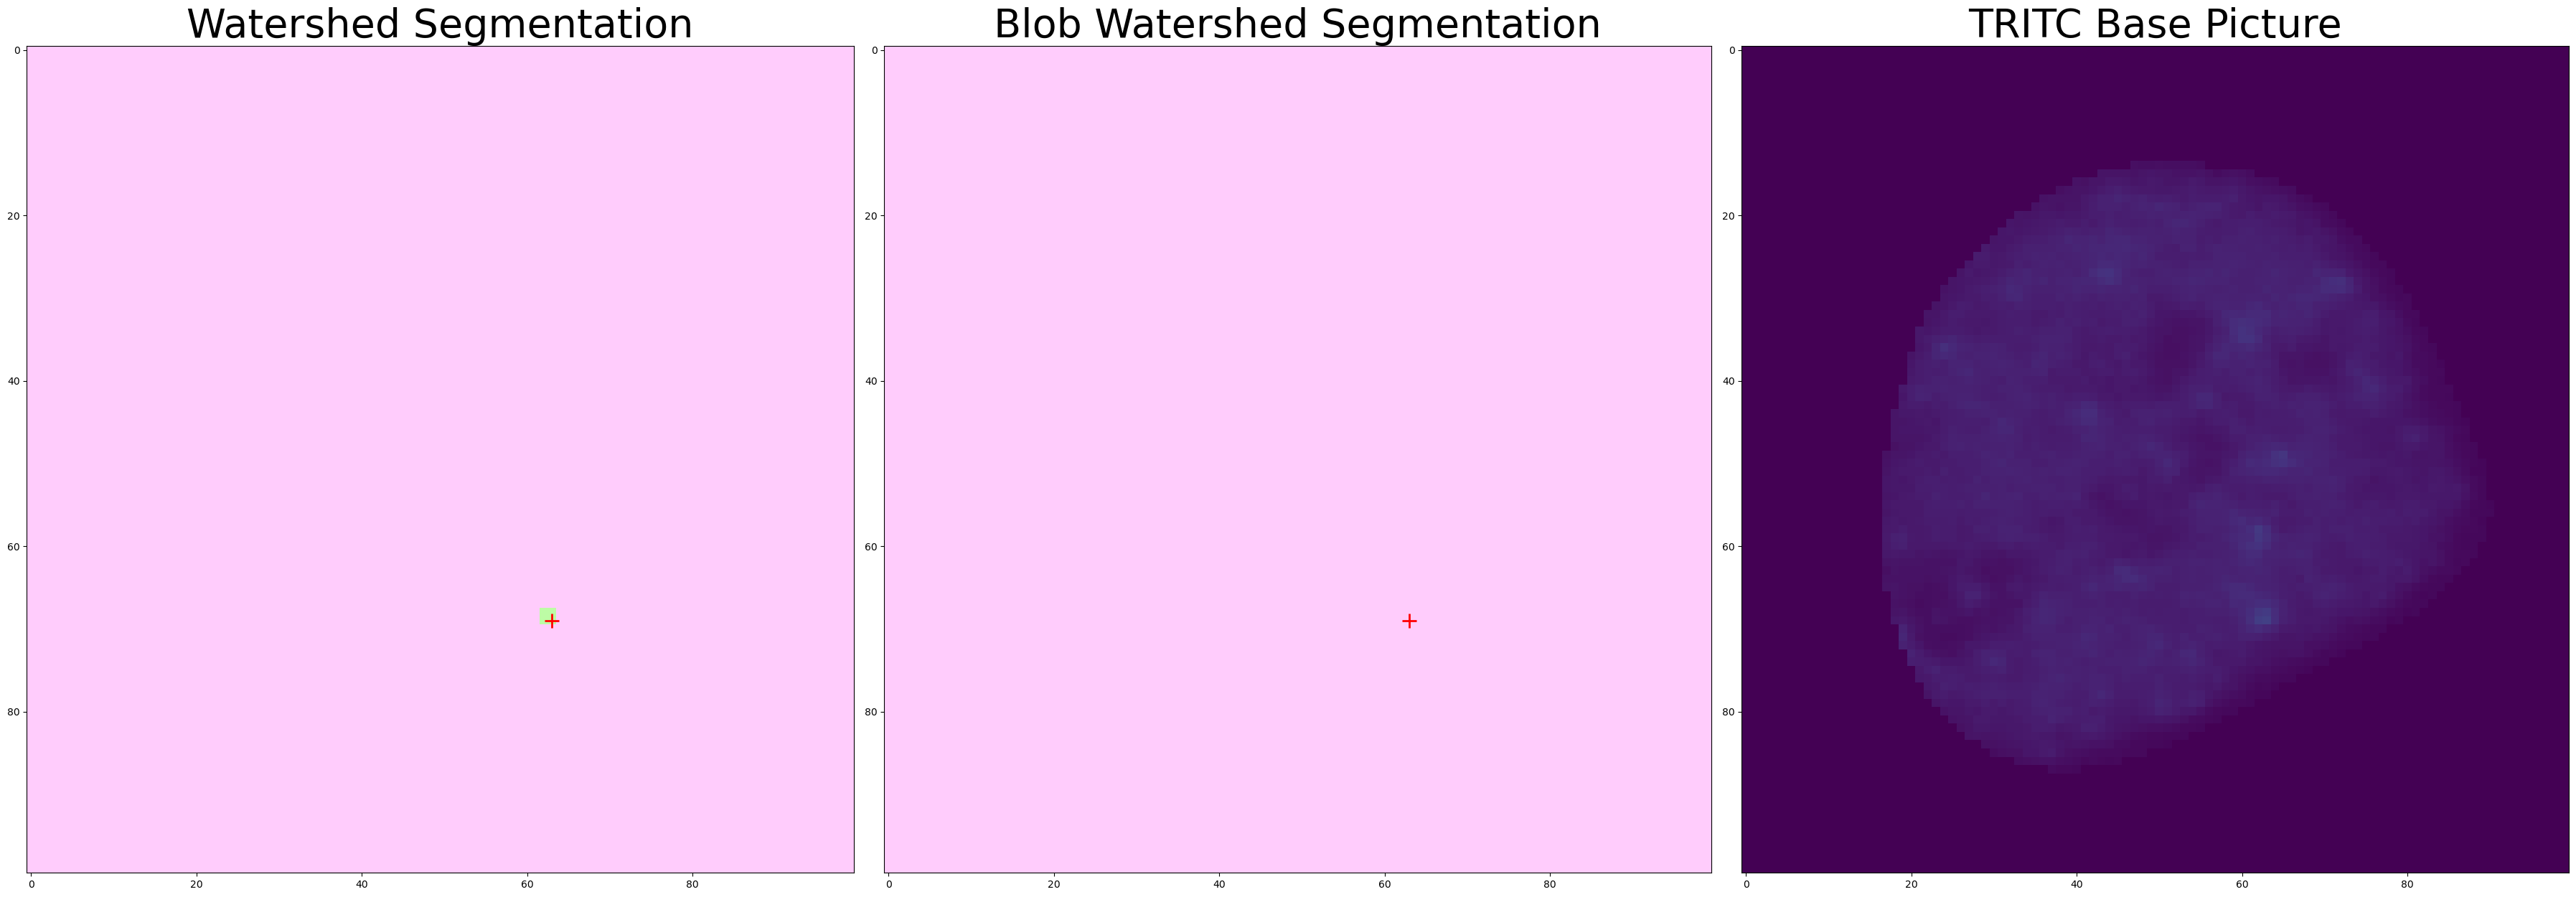

In [17]:
# Displaying the original picture with an isolated cell and the filtered picture
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(36, 12))

# Finding the middle coordinates for the cell we want to look at
props = regionprops(masks_reduced.astype(int))  # Calculate region properties (centroid, area, etc.) for the cell mask
if props:  # Check if any regions (props) were found in the mask
    centroid_y, centroid_x = props[0].centroid  # Extract y and x coordinates of the cell's center, which is the only region (props[0])

# To stop the possibility of going out of boundary
if int(centroid_y) < 50:
    centroid_y = 50
if int(centroid_x) < 50:
    centroid_x = 50

# Initial crop
origin = ((int(centroid_y)-50),(int(centroid_x)-50))
#origin = (0,0)
size = (100,100) #~100x100 for single cell
#size = (2048,2048)






# Show the watershed labels as colored regions
axes[0].imshow(water_labels[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], cmap = 'vanimo')

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted[:, 0] >= 0) & (adjusted[:, 0] < size[0]) & \
       (adjusted[:, 1] >= 0) & (adjusted[:, 1] < size[1])
visible = adjusted[mask]

# Plot the peaks
axes[0].plot(visible[:, 1], visible[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[0].set_title('Watershed Segmentation', fontsize = 40)



# Show the watershed labels as colored regions
axes[1].imshow(blob_labels[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], cmap = 'vanimo')

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted[:, 0] >= 0) & (adjusted[:, 0] < size[0]) & \
       (adjusted[:, 1] >= 0) & (adjusted[:, 1] < size[1])
visible = adjusted[mask]

# Plot the peaks
axes[1].plot(visible[:, 1], visible[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[1].set_title('Blob Watershed Segmentation', fontsize = 40)


axes[2].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())
axes[2].set_title('TRITC Base Picture', fontsize = 40)

plt.tight_layout()
plt.show

Text(0.5, 1.0, 'DAPI')

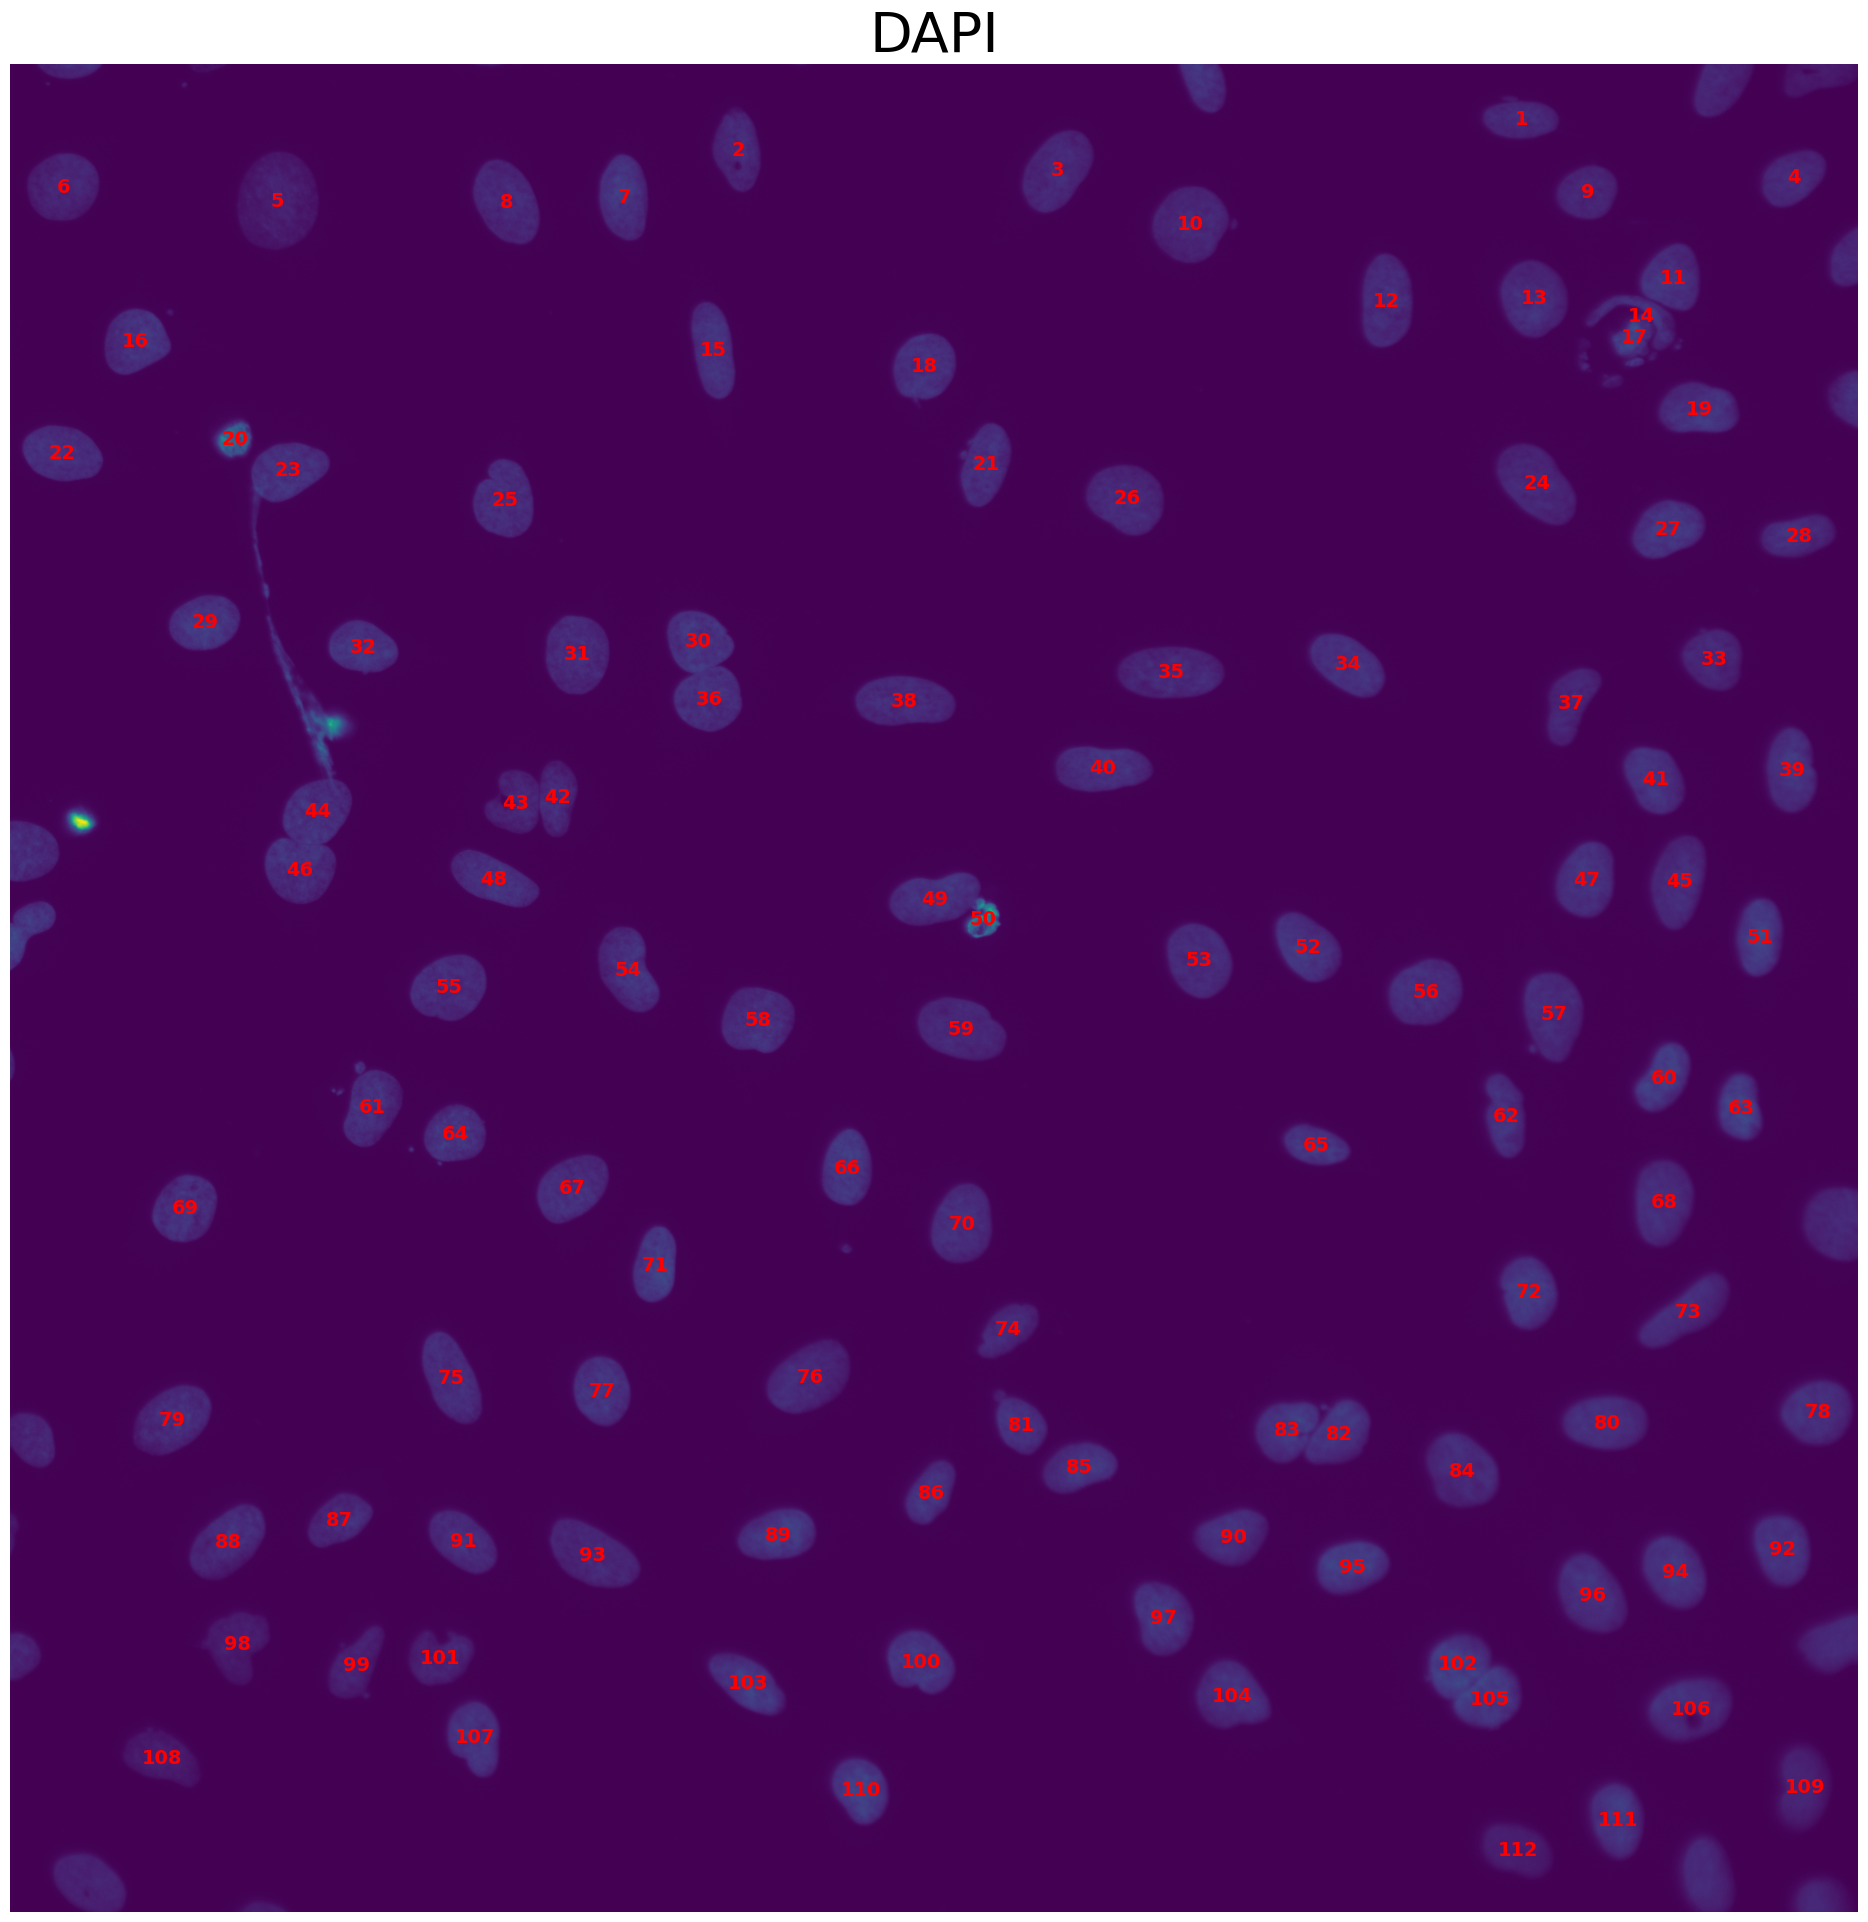

In [11]:
# Plotting Masks
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(36, 24))

# Original DAPI Picture
axes.imshow(DAPI_pic)

# Adding numbers to the Individual nuclei to identify them easier
nums = regionprops(masks)
for prop in nums:
    #Getting the coordinates of the center of the nuclei
    y, x = prop.centroid  # getting the x and y coordinates
    label = prop.label   # getting the number of the nucleus at that position

    # Adding the text at the location of the centroids
    axes.text(x, y, str(label), color = 'red', fontsize = 14, ha = 'center', va = 'center', weight = 'bold')

axes.axis('off')
axes.set_title('DAPI', fontsize = 40)

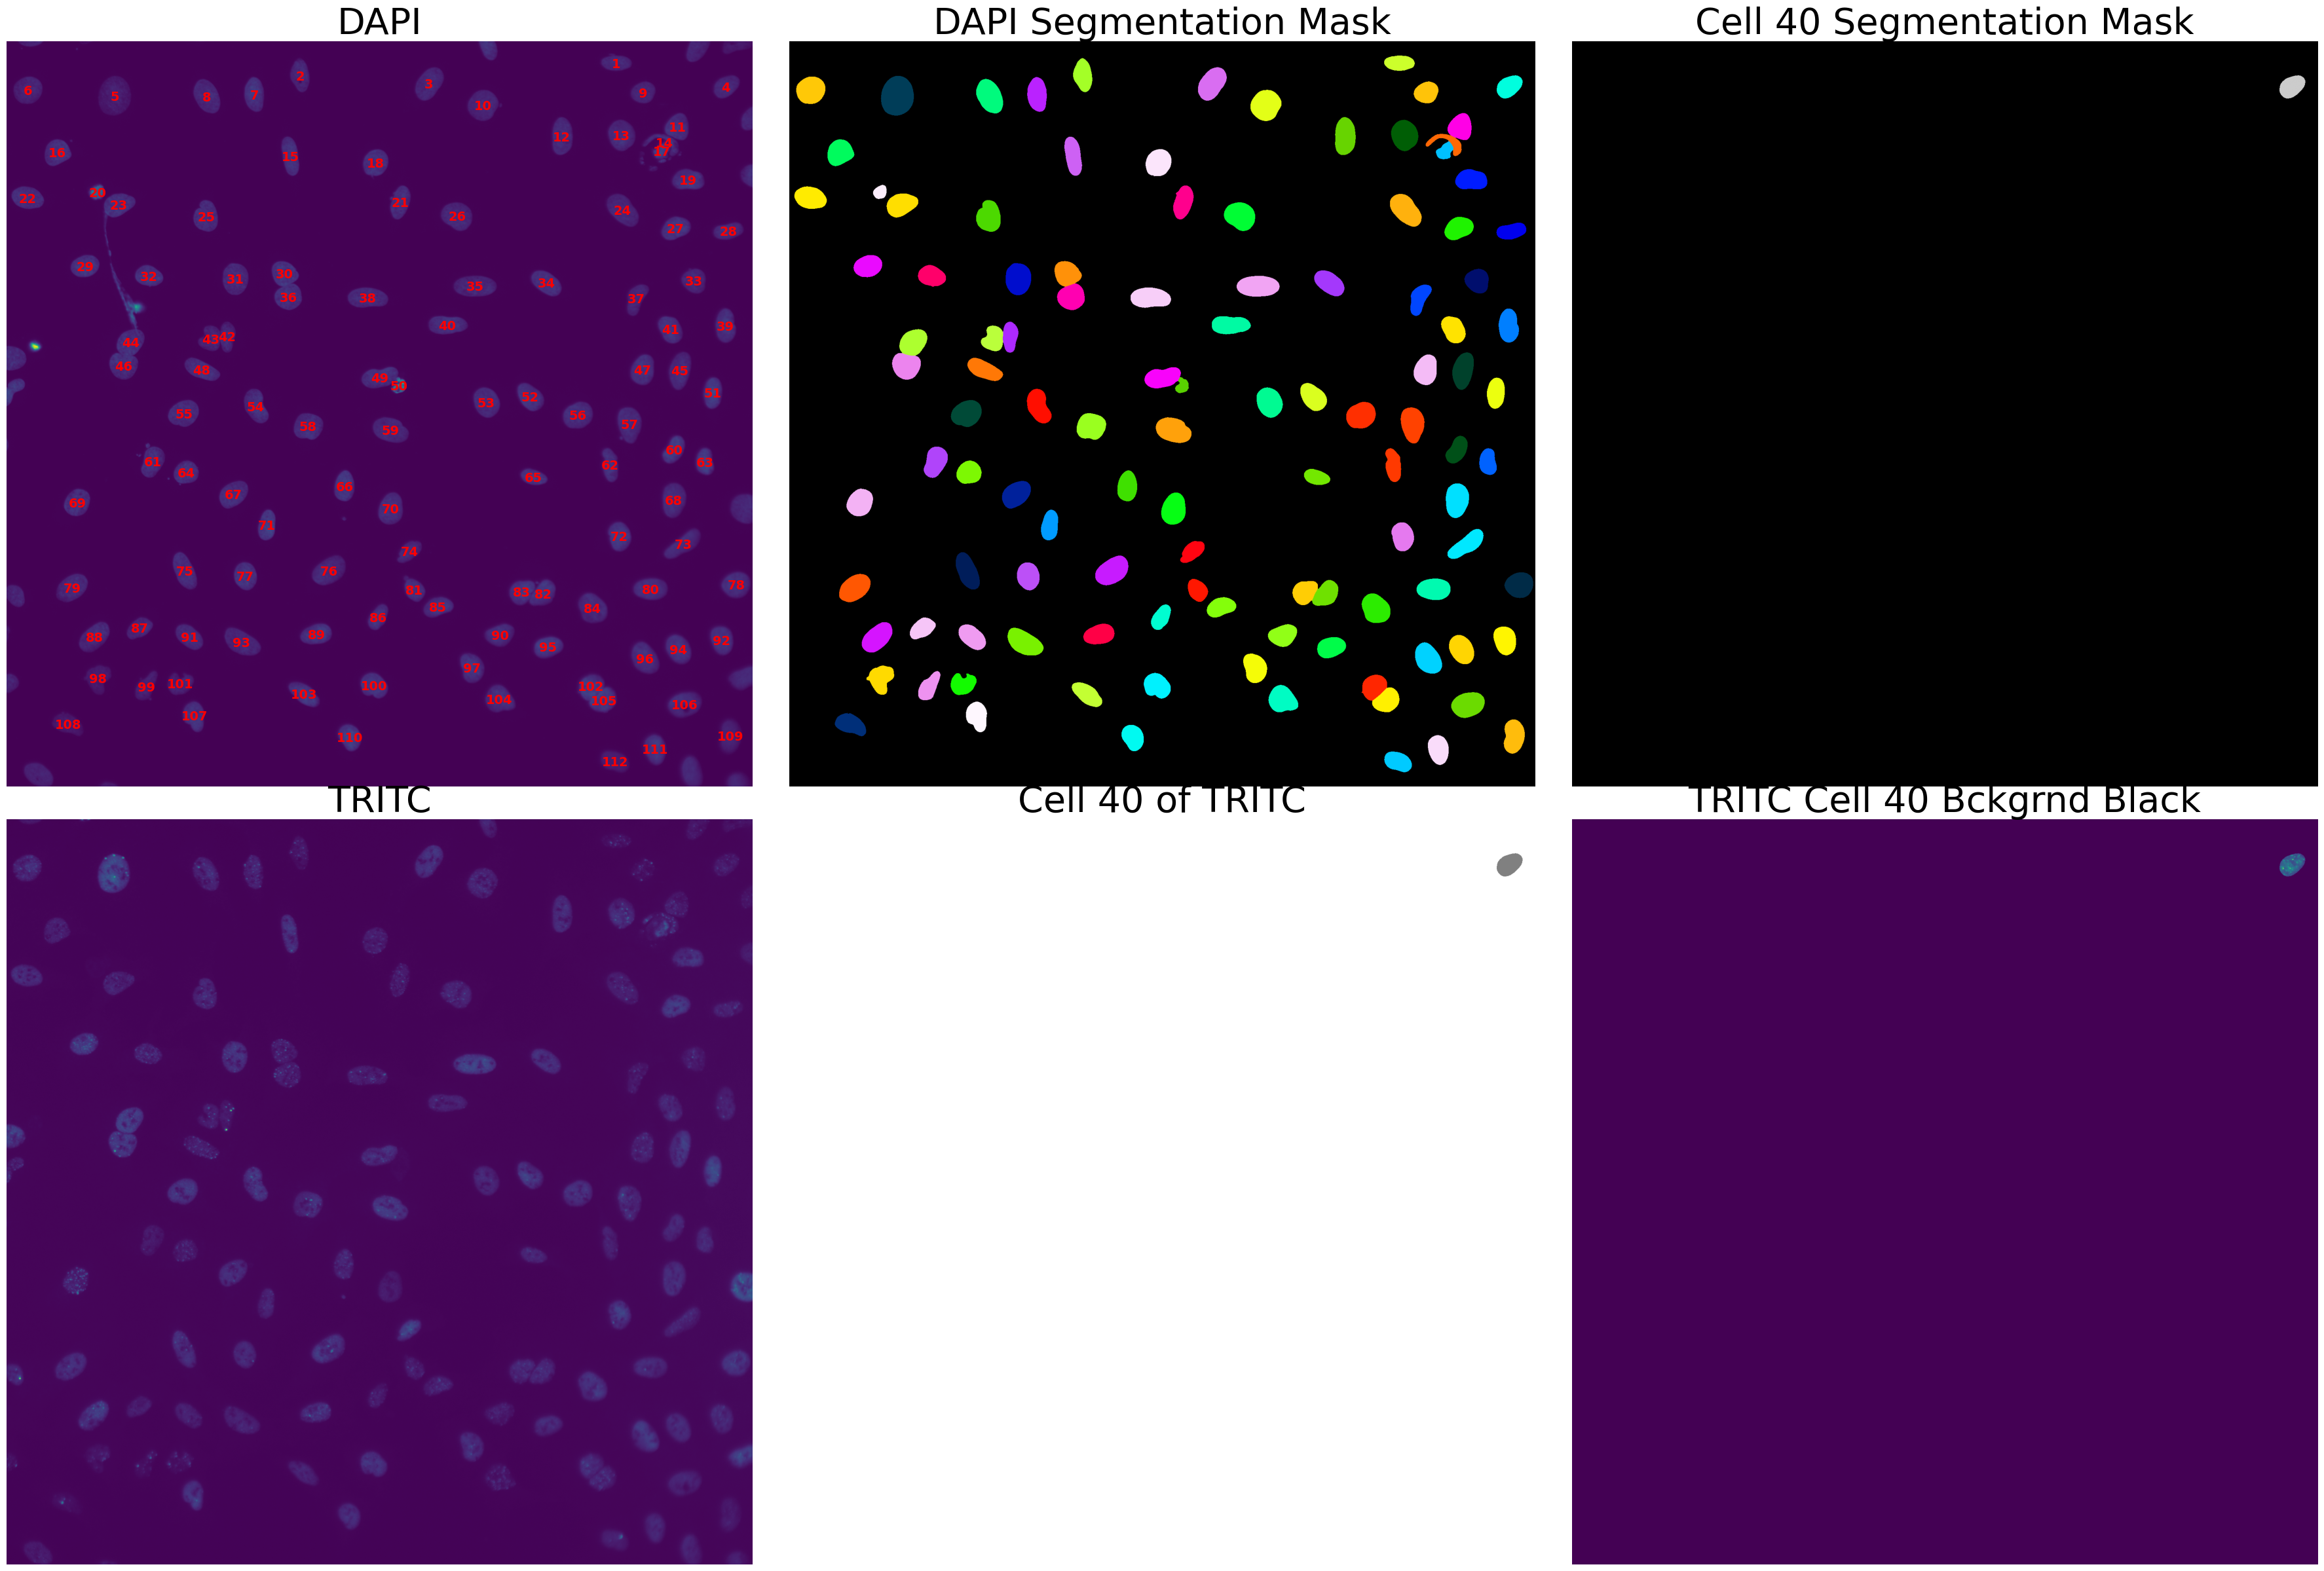

In [12]:
# Plotting Masks
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(36, 24))

# Original DAPI Picture
axes[0,0].imshow(DAPI_pic)

# Adding numbers to the Individual nuclei to identify them easier
nums = regionprops(masks)
for prop in nums:
    #Getting the coordinates of the center of the nuclei
    y, x = prop.centroid  # getting the x and y coordinates
    label = prop.label   # getting the number of the nucleus at that position

    # Adding the text at the location of the centroids
    axes[0,0].text(x, y, str(label), color = 'red', fontsize = 14, ha = 'center', va = 'center', weight = 'bold')

axes[0,0].axis('off')
axes[0,0].set_title('DAPI', fontsize = 40)

# Create a shuffled colormap to randomize colors
#np.random.seed(37)  # Makes the colors always the same
num_labels = masks.max()  # Gets the highest number from the nuclei to know how many there are

# Generate random colors for each nucleus (so for 150 nuclei there are 150 colors generated +1 for the background)
colors = plt.cm.gist_ncar(np.linspace(0, 1, num_labels + 1))
np.random.shuffle(colors[1:])  # Shuffle all colors starting at 1 except background (index 0)

# Set background to black: colors[0] to black [R=0, G=0, B=0, Alpha=1] so the background is always black
colors[0] = [0, 0, 0, 1]  

# Create custom colormap, listedColormap takes the array of colors and creates a matplotlib colormap object
custom_cmap = ListedColormap(colors)

# Create display mask with proper color indexing
masks_display = masks.copy()
# Normalize to 0-1 range for colormap
axes[0,1].imshow(masks_display, cmap=custom_cmap, vmin=0, vmax=num_labels)
axes[0,1].axis('off')
axes[0,1].set_title('DAPI Segmentation Mask', fontsize=40)

# Singular Nucleus isolated from Mask
axes[0,2].imshow(masks_reduced, cmap='nipy_spectral')
axes[0,2].axis('off')
axes[0,2].set_title('Cell 40 Segmentation Mask', fontsize = 40)

# Original TRITC Picture
axes[1,0].imshow(TRITC_pic)
axes[1,0].axis('off')
axes[1,0].set_title('TRITC', fontsize = 40)

# Mask overlaying the TRITC Picture
axes[1,1].imshow(masked_TRITC, cmap='nipy_spectral', alpha=0.5)
axes[1,1].axis('off')
axes[1,1].set_title('Cell 40 of TRITC', fontsize = 40)

#show TRITC with applied mask
axes[1,2].imshow(isolated_TRITC)
axes[1,2].axis('off')
axes[1,2].set_title('TRITC Cell 40 Bckgrnd Black', fontsize = 40)

plt.tight_layout()
plt.show()